# HARQ Model on the MHAR 5-min Feature Set

**Purpose:** The purpose of this notebook is to compute the out-of-sample forecast performance 
of the Heterogeneous Autoregressive model with realized quarticity (HARQ) on the 
$\mathcal{M}_{\mathrm{HAR}}$ 5-min feature set for the EURO STOXX 50 index over the 
period 1999–2020, following the methodology of Christensen et al. (2023).

The model is defined as:

$$RV_{t+1} = \beta_0 + \left(\beta_d + \beta_q \sqrt{RQ_t}\right) RV_t + \beta_w \overline{RV}_t^{(w)} + 
\beta_m \overline{RV}_t^{(m)} + \varepsilon_{t+1}$$

where the predictors are the current day's realized variance measures and realized quarticity term:

- $RV_t$ (RVD) — daily realized variance
- $\overline{RV}_t^{(w)} = \frac{1}{5}\sum_{i=0}^{4} RV_{t-i}$ (RVW) — 
5-day rolling average of realized variance
- $\overline{RV}_t^{(m)} = \frac{1}{22}\sum_{i=0}^{21} RV_{t-i}$ (RVM) — 
22-day rolling average of realized variance
- $RQ_t$ — daily realized quarticity

The realized quarticity term is included to account for time-varying measurement error in the daily realized variance measure, allowing the effect of the daily component to vary with the noisiness of the volatility estimate.

The model is estimated via Ordinary Least Squares (OLS) using a rolling window 
of fixed length equal to the combined training and validation set (4,389 
observations), rolling forward one day at a time across the test period of 
1,099 observations (2016-04-20 to 2020-08-05).

## 1. Loading Data
Loading in data from the MALL_5min.csv file

In [5]:
import pandas as pd
import numpy as np

# Load MALL dataset
file_path = "/Users/tobiasbergdahlpersson/Documents/SSE/MSc Thesis/5-min RV/Cleaned Data Sets/MALL_5min.csv"
MALL = pd.read_csv(file_path, index_col='Date', parse_dates=True)

print(f"Shape: {MALL.shape}")
print(f"Date range: {MALL.index[0].date()} to {MALL.index[-1].date()}")
print(f"NaN values: {MALL.isna().sum().sum()}")
MALL.head()

Shape: (5489, 31)
Date range: 1999-01-05 to 2020-08-06
NaN values: 0


,RVD,RVW,RVM,logRVD,logRVW,logRVM,RVD_pos,RVD_neg,RD_neg,RW_neg,...,BRENT,BRENT_ret,NIKKEI_ret,NIKKEI_sq,SP500_ret_lag,SP500_sq_lag,M1W,M1M,RV_target,logRV_target
Date,,,,,,,,,,,,,,,,,,,,,
1999-01-05,0.000106,0.000089,0.000141,-9.153100,-9.328531,-8.866447,0.000071,0.000035,0.000000,-0.000960,...,10.30,-0.060282,-0.013746,0.000189,-0.000920,8.458434e-07,0.087690,0.126206,0.000047,-9.966398
1999-01-06,0.000047,0.000090,0.000132,-9.966398,-9.316927,-8.935760,0.000038,0.000009,0.000000,-0.000960,...,10.67,0.035292,0.017657,0.000312,0.013491,1.819949e-04,0.100143,0.187219,0.000237,-8.347779
1999-01-07,0.000237,0.000123,0.000131,-8.347779,-9.004761,-8.938374,0.000110,0.000127,-0.012859,-0.003532,...,11.08,0.037706,0.005044,0.000025,0.021899,4.795626e-04,0.078881,0.184020,0.000168,-8.689606
1999-01-08,0.000168,0.000146,0.000114,-8.689606,-8.832472,-9.082830,0.000079,0.000089,-0.005883,-0.003748,...,11.70,0.054447,-0.010751,0.000116,-0.002053,4.216638e-06,0.078883,0.165510,0.000282,-8.175339
1999-01-11,0.000282,0.000168,0.000117,-8.175339,-8.692020,-9.056351,0.000067,0.000215,-0.025309,-0.008810,...,12.07,0.031134,-0.001744,0.000003,0.004212,1.774503e-05,0.001055,0.140613,0.000191,-8.565468


## 2. Data Split
### 2.1 Train / Validation / Test Split (70 / 10 / 20)

Following Christensen et al. (2023), we split the sample into a training set (70%), 
validation set (10%), and test set (20%). The test set is reserved exclusively for 
out-of-sample evaluation and no estimation or tuning is conducted on it.

In [10]:
# Train / Validation / Test split (70 / 10 / 20)
n = len(MALL)
n_train = int(np.floor(0.70 * n))
n_val   = int(np.floor(0.10 * n))
n_test  = n - n_train - n_val

train_idx = MALL.index[:n_train]
val_idx   = MALL.index[n_train:n_train + n_val]
test_idx  = MALL.index[n_train + n_val:]

print(f"Total observations: {n}")
print(f"\nTrain:      {train_idx[0].date()} to {train_idx[-1].date()} ({n_train} obs, {n_train/n*100:.1f}%)")
print(f"Validation: {val_idx[0].date()} to {val_idx[-1].date()} ({n_val} obs, {n_val/n*100:.1f}%)")
print(f"Test:       {test_idx[0].date()} to {test_idx[-1].date()} ({n_test} obs, {n_test/n*100:.1f}%)")

Total observations: 5489

Train:      1999-01-05 to 2014-02-26 (3842 obs, 70.0%)
Validation: 2014-02-27 to 2016-04-20 (548 obs, 10.0%)
Test:       2016-04-21 to 2020-08-06 (1099 obs, 20.0%)


## 3. HAR Model
### 3.1 Model Specification

The HARQ benchmark augments the baseline HAR structure with a quarticity-scaled daily variance interaction:

$$RV_{t+1} = \beta_0 + \beta_d RV_t + \beta_{dQ} \left(RV_t \sqrt{RQ_t}\right) + \beta_w \overline{RV}^{(w)}_t + \beta_m \overline{RV}^{(m)}_t + \varepsilon_{t+1}$$

where `RQ` is realized quarticity and the interaction term `RVD_x_sqrtRQ` scales the daily realized variance component according to the intraday noise environment at time $t$.


### 3.2 Feature Set Construction
Extracting the dependent and independent variables relevant for the HAR model

In [15]:
# Define target and feature set for HARQ on MHAR
y = MALL["RV_target"]
MALL["sqrtRQ"] = np.sqrt(MALL["RQ"])
MALL["RVD_x_sqrtRQ"] = MALL["RVD"] * MALL["sqrtRQ"]
X_MHAR = MALL[["RVD", "RVD_x_sqrtRQ", "RVW", "RVM"]]

print("Target variable: RV_target")
print(f"Predictors: {X_MHAR.columns.tolist()}")
print(f"\nFirst few rows:")
print(pd.concat([y, X_MHAR], axis=1).head())

Target variable: RV_target
Predictors: ['RVD', 'RVD_x_sqrtRQ', 'RVW', 'RVM']

First few rows:
            RV_target       RVD  RVD_x_sqrtRQ       RVW       RVM
Date                                                             
1999-01-05   0.000047  0.000106  1.265217e-08  0.000089  0.000141
1999-01-06   0.000237  0.000047  2.509107e-09  0.000090  0.000132
1999-01-07   0.000168  0.000237  6.637373e-08  0.000123  0.000131
1999-01-08   0.000282  0.000168  3.223270e-08  0.000146  0.000114
1999-01-11   0.000191  0.000282  1.366070e-07  0.000168  0.000117


### 3.3 Rolling Window Estimation and Forecasting

Following Christensen et al. (2023), the HARQ model is estimated via OLS using a rolling 
window of fixed length equal to the combined training and validation set (3,842 + 548 = 4,390 
observations). The window rolls forward one day at a time across the test set, producing 
one-step-ahead forecasts. Negative forecasts are replaced by the minimum in-sample realized 
variance following the insanity filter of Bollerslev, Patton, and Quaedvlieg (2016).

In [18]:
from sklearn.linear_model import LinearRegression

# Rolling window length = train + validation
window = n_train + n_val

forecasts_HARQ = []
dates_test = []

for i in range(n_test):
    # Extract rolling window
    X_window = X_MHAR.iloc[i : i + window].values
    y_window = y.iloc[i : i + window].values

    # OLS estimation in levels
    model = LinearRegression()
    model.fit(X_window, y_window)

    # One-step-ahead forecast using time t predictors
    X_forecast = X_MHAR.iloc[i + window].values.reshape(1, -1)
    forecast = model.predict(X_forecast)[0]

    # Insanity filter: replace negative forecasts with minimum in-sample RV
    min_rv = y_window.min()
    forecast = max(forecast, min_rv)

    forecasts_HARQ.append(forecast)
    dates_test.append(MALL.index[i + window])

print(f"Forecasts generated: {len(forecasts_HARQ)}")
print(f"Forecast period: {dates_test[0].date()} to {dates_test[-1].date()}")

Forecasts generated: 1099
Forecast period: 2016-04-21 to 2020-08-06


### 3.4 Out-of-Sample Performance Evaluation

Following Christensen et al. (2023), out-of-sample forecast accuracy is evaluated using 
the Mean Squared Error (MSE):

$$MSE = \frac{1}{T}\sum_{t \in \text{test}} (RV_{t+1} - \hat{f}(Z_t))^2$$

where $\hat{f}(Z_t)$ is the one-step-ahead forecast and $T$ is the number of test observations.

In [22]:
# Collect results
results_HARQ = pd.DataFrame({
    "RV_actual": y.loc[dates_test].values,
    "RV_forecast": forecasts_HARQ
}, index=dates_test)

# Compute out-of-sample MSE
mse_HARQ = np.mean((results_HARQ["RV_actual"] - results_HARQ["RV_forecast"])**2)

print(f"Out-of-sample MSE (HARQ): {mse_HARQ:.6e}")
print(f"\nFirst few forecasts vs actuals:")
print(results_HARQ.head(10).to_string())

Out-of-sample MSE (HARQ): 4.792463e-08

First few forecasts vs actuals:
            RV_actual  RV_forecast
2016-04-21   0.000053     0.000104
2016-04-22   0.000081     0.000070
2016-04-25   0.000066     0.000085
2016-04-26   0.000059     0.000077
2016-04-27   0.000097     0.000072
2016-04-28   0.000147     0.000094
2016-04-29   0.000095     0.000128
2016-05-02   0.000105     0.000099
2016-05-03   0.000085     0.000107
2016-05-04   0.000093     0.000097


### 3.4.1 Save Forecasts

In [25]:
import os

# Paths
forecast_path = "/Users/tobiasbergdahlpersson/Documents/SSE/MSc Thesis/5-min RV/Cleaned Data Sets/Forecasts 5-min/MHAR/Benchmark Models"
mse_path = "/Users/tobiasbergdahlpersson/Documents/SSE/MSc Thesis/5-min RV/Cleaned Data Sets/MSE 5-min/MHAR/Benchmark Models"

# Create BOTH directories
os.makedirs(forecast_path, exist_ok=True)
os.makedirs(mse_path, exist_ok=True)

# -------------------
# Save forecasts (HARQ)
# -------------------
results_HARQ.to_csv(os.path.join(forecast_path, "forecasts_HARQ.csv"))

# -------------------
# Create MSE summary (HARQ)
# -------------------
mse_summary_HARQ = pd.DataFrame({
    "Model": ["HARQ"],
    "MSE":   [mse_HARQ],
    "RMSE":  [np.sqrt(mse_HARQ)],
    "MAE":   [np.mean(np.abs(results_HARQ["RV_actual"] - results_HARQ["RV_forecast"]))],
    "Mean_Error": [np.mean(results_HARQ["RV_actual"] - results_HARQ["RV_forecast"])],
}).set_index("Model")

# -------------------
# Save MSE
# -------------------
mse_summary_HARQ.to_csv(os.path.join(mse_path, "mse_summary_HARQ.csv"))

# -------------------
# Print
# -------------------
print(f"Forecasts saved to: {forecast_path}")
print(f"MSE saved to: {mse_path}")
print("Files saved:")
print(f"  - forecasts_HARQ.csv ({len(results_HARQ)} rows)")
print("  - mse_summary_HARQ.csv")
print(f"\nHARQ MSE: {mse_HARQ:.6e}")

Forecasts saved to: /Users/tobiasbergdahlpersson/Documents/SSE/MSc Thesis/5-min RV/Cleaned Data Sets/Forecasts 5-min/MHAR/Benchmark Models
MSE saved to: /Users/tobiasbergdahlpersson/Documents/SSE/MSc Thesis/5-min RV/Cleaned Data Sets/MSE 5-min/MHAR/Benchmark Models
Files saved:
  - forecasts_HARQ.csv (1099 rows)
  - mse_summary_HARQ.csv

HARQ MSE: 4.792463e-08


## 4. Results
### 4.1 Forecast Visualization

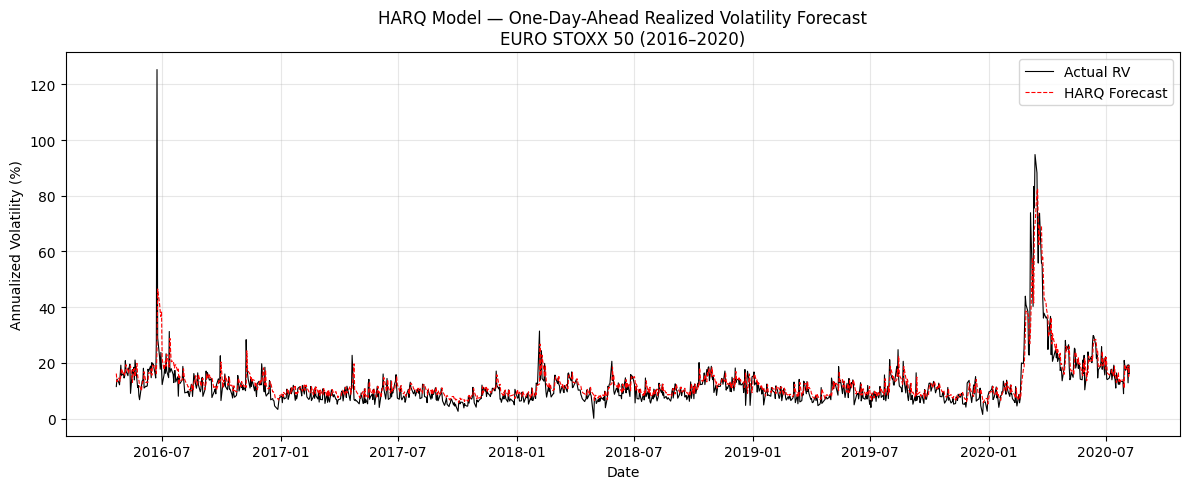


Summary of forecast errors:
Mean error:  -4.991111e-07
RMSE:        2.189169e-04
MAE:         4.419470e-05


In [29]:
import matplotlib.pyplot as plt

# Convert to annualized volatility for readability
results_plot = pd.DataFrame({
    "Actual":   np.sqrt(results_HARQ["RV_actual"] * 252) * 100,
    "Forecast": np.sqrt(results_HARQ["RV_forecast"] * 252) * 100
}, index=results_HARQ.index)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(results_plot["Actual"],   label="Actual RV",       color="black", linewidth=0.8)
ax.plot(results_plot["Forecast"], label="HARQ Forecast",   color="red",   linewidth=0.8, linestyle="--")

ax.set_title("HARQ Model — One-Day-Ahead Realized Volatility Forecast\nEURO STOXX 50 (2016–2020)", fontsize=12)
ax.set_ylabel("Annualized Volatility (%)")
ax.set_xlabel("Date")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# -------------------
# Error metrics
# -------------------
print(f"\nSummary of forecast errors:")
errors = results_HARQ["RV_actual"] - results_HARQ["RV_forecast"]

print(f"Mean error:  {errors.mean():.6e}")
print(f"RMSE:        {np.sqrt(mse_HARQ):.6e}")
print(f"MAE:         {errors.abs().mean():.6e}")